# Fig 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pingouin as pg


import src.plot_graph as spg
import src.stat_utils as ssu
import src.distance_utils as sdu
import src.stat_test_utils as stu
import src.graph_utils as sgu
import src.plot_analysis as spa
import src.annot_plot as sap
import src.mixed_model as smm

import src.augment_data as sad

from src.config import PATHS, dark_brown_palette, dark_orange_palette, palette

In [2]:
%load_ext autoreload
%autoreload 2

## Load Data

In [3]:
core_dt_all, task1_dt_all, task2_dt_all, task3_dt_all, task4_dt_all, task3_4_dt_all = sad.load_full_data(
    excl_incompl=True,
    excl_cheaters=True,
    excl_uncertains=True,
    verbose=0,
)

In [4]:
# Include all participants
core_dt = core_dt_all
task1_dt  = task1_dt_all
task1_dt = task1_dt_all
task2_dt = task2_dt_all
task3_dt = task3_dt_all
task4_dt = task4_dt_all
task3_4_dt = task3_4_dt_all

In [5]:
adj_m = core_dt["adj_m"].iloc[0]
spd_m = core_dt["spd_m"].iloc[0]
wadj_m = core_dt["posw_adj_m"].iloc[0]
wspd_m = core_dt["wspd_m"].iloc[0]
eucd_m = core_dt["eucd_m"].iloc[0]
rand_pos = core_dt["node_positions"].iloc[-1]

## Panel a & b: Positioning grid & Six exemplar random layouts

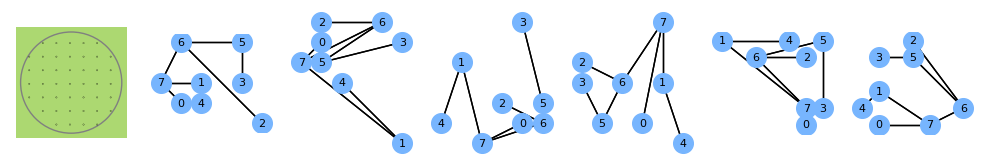

In [6]:
n_colors = ["#b1d5fe", "#77b5fe"]

fig, axs = plt.subplots(1,7, figsize=(10,2.2))
spg.axplot_graph(adj_m, None, env_size=[900, 900], alpha=0.0, circ_rad=900/2-40, grid_spacing=110, ax=axs[0])
spg.axplot_graph(adj_m, pos=rand_pos[1], node_color=n_colors[1], ax=axs[1])
spg.axplot_graph(adj_m, pos=rand_pos[2], node_color=n_colors[1], ax=axs[2])
spg.axplot_graph(adj_m, pos=rand_pos[3], node_color=n_colors[1], ax=axs[3])
spg.axplot_graph(adj_m, pos=rand_pos[4], node_color=n_colors[1], ax=axs[4])
spg.axplot_graph(adj_m, pos=rand_pos[5], node_color=n_colors[1], ax=axs[5])
spg.axplot_graph(adj_m, pos=rand_pos[6], node_color=n_colors[1], ax=axs[6])
for ax in axs:
    ax.set_aspect('equal')

fig.tight_layout()
plt.show()

## Panel c: Accuracy (Probe)


In [19]:
task2_dt_unc = task2_dt.query("var_type == 'unconstrained'")
task2_dt_rot = task2_dt.query("var_type == 'rotational'")

               T  dof alternative         p-val         CI95%   cohen-d  \
T-test  9.223316   42   two-sided  1.184344e-11  [0.65, 0.74]  1.406542   

             BF10  power  
T-test  7.789e+08    1.0  


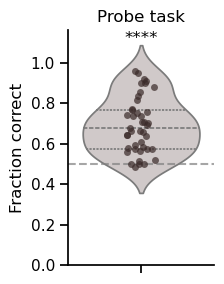

In [20]:
fig, axs = plt.subplots(1,1, figsize=(2.4,3.0))
spa.axplot_task2_all(task2_dt_unc, key="acc_learnrelquest", 
                     color=["#D1C8C8", "#3A2A29"],  
                     verbose=3, ax=axs)
axs.set_title("Probe task")
axs.set_ylim([0, 1.16])
fig.tight_layout()

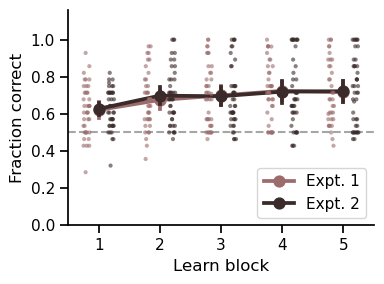

In [21]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
spa.axplot_task2_paired(task2_dt, "acc_learnrelquest", hline=0.5, ax=ax)
ax.set_ylim([0, 1.16])
# fig.suptitle(f"Learning (Task 2) - Experiment 1+2")
fig.tight_layout()

In [23]:
x = task2_dt_rot.groupby("subject_id")["acc_learnrelquest"].mean()
y = task2_dt_unc.groupby("subject_id")["acc_learnrelquest"].mean()
print(x.describe())
print(y.describe())
ttest = pg.ttest(x, y)
stu.stat_report(ttest)

count    40.000000
mean      0.686342
std       0.117900
min       0.471429
25%       0.610714
50%       0.667746
75%       0.730357
max       0.971429
Name: acc_learnrelquest, dtype: float64
count    43.000000
mean      0.692948
std       0.137179
min       0.485714
25%       0.575000
50%       0.678571
75%       0.767857
max       0.957143
Name: acc_learnrelquest, dtype: float64


'$t(81) = -0.24$, $p = 0.814$, $\text{BF}_{10} = 0.23$, $d = 0.05$'

In [24]:
ttest = pg.ttest(y, 0)

stu.stat_report(ttest)

'$t(42) = 33.12$, $p < .001$, $\text{BF}_{10} = 2.23e+28$, $d = 5.05$'

In [26]:
x = task2_dt_rot.groupby("subject_id")["rt_learnrelquest"].mean()
y = task2_dt_unc.groupby("subject_id")["rt_learnrelquest"].mean()
print(x.describe())
print(y.describe())

ttest = pg.ttest(x, y)

print(stu.stat_report(ttest))
ttest

count    40.000000
mean      2.511688
std       1.373354
min       0.466007
25%       1.679891
50%       2.247179
75%       2.925446
max       7.191421
Name: rt_learnrelquest, dtype: float64
count    43.000000
mean      2.285560
std       1.218464
min       0.488429
25%       1.656936
50%       2.077843
75%       2.425807
max       6.862664
Name: rt_learnrelquest, dtype: float64
$t(78) = 0.79$, $p = 0.431$, $	ext{BF}_{10} = 0.30$, $d = 0.17$


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.791221,78.127548,two-sided,0.431211,"[-0.34, 0.8]",0.174568,0.301,0.123085


In [28]:
task2_dt_unc.query("type == 'first'").groupby("subject_id")["acc_learnrelquest"].mean().describe()

count    43.000000
mean      0.627492
std       0.107467
min       0.321429
25%       0.535714
50%       0.642857
75%       0.714286
max       0.821429
Name: acc_learnrelquest, dtype: float64

In [29]:
task2_dt_unc.query("type == 'fifth'").groupby("subject_id")["acc_learnrelquest"].mean().describe()

count    43.000000
mean      0.722315
std       0.183983
min       0.464286
25%       0.535714
50%       0.714286
75%       0.857143
max       1.000000
Name: acc_learnrelquest, dtype: float64

## Panel d: Accuracy (Path-Choice)

              T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test  2.45309   42   two-sided  0.018397  [0.51, 0.61]  0.374093  2.368   

           power  
T-test  0.668855  


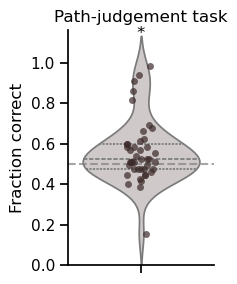

In [30]:
fig, axs = plt.subplots(1,1, figsize=(2.4,3.))
task3_dt_unc = task3_dt.query("var_type == 'unconstrained'")
spa.axplot_task2_all(task3_dt_unc, key="acc_spd", 
                    color=["#D1C8C8", "#3A2A29"],  
                     verbose=3, ax=axs)
axs.set_title("Path-judgement task")
axs.set_ylim([0, 1.16])
fig.tight_layout()

In [31]:
rot_dt = task3_4_dt.query("var_type == 'rotational'")
unc_dt = task3_4_dt.query("var_type == 'unconstrained'")
x = rot_dt.groupby("subject_id")["acc_spd"].mean()
y = unc_dt.groupby("subject_id")["acc_spd"].mean()

pg.ttest(y, 0.5)
# pg.ttest(x, 0.5)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.45309,42,two-sided,0.018397,"[0.51, 0.61]",0.374093,2.368,0.668855


In [32]:
print(x.describe())
print(y.describe())
ttest = pg.ttest(x, y)

ttest
# stu.stat_report(ttest)

count    40.000000
mean      0.590266
std       0.141006
min       0.338462
25%       0.476923
50%       0.553846
75%       0.661538
max       0.953846
Name: acc_spd, dtype: float64
count    43.000000
mean      0.558454
std       0.156255
min       0.153846
25%       0.476923
50%       0.523077
75%       0.600000
max       0.984615
Name: acc_spd, dtype: float64


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.974861,80.929977,two-sided,0.332534,"[-0.03, 0.1]",0.213349,0.346,0.160352


In [33]:
print(y.describe())
ttest = pg.ttest(y, 0.5)
ttest

stu.stat_report(ttest)

count    43.000000
mean      0.558454
std       0.156255
min       0.153846
25%       0.476923
50%       0.523077
75%       0.600000
max       0.984615
Name: acc_spd, dtype: float64


'$t(42) = 2.45$, $p = 0.018$, $\text{BF}_{10} = 2.37$, $d = 0.37$'

## Arena Task Correlations

In [34]:
task4_dt_unc = task4_dt[task4_dt["var_type"]=="unconstrained"]
mm4_dt_unc = smm.prepare_mm4_dt(task4_dt_unc, zscore_flag=False)

task4_dt_rot = task4_dt[task4_dt["var_type"]=="rotational"]
mm4_dt_rot = smm.prepare_mm4_dt(task4_dt_rot, zscore_flag=False)

task3_4_dt_rot = task3_4_dt.query("var_type == 'rotational'")
subj_not_connect_rot = sad.subjects_not_connect(task3_4_dt_rot)
task3_4_dt_unc = task3_4_dt.query("var_type == 'unconstrained'")
subj_not_connect_unc = sad.subjects_not_connect(task3_4_dt_unc)


mm4_dt_rot = mm4_dt_rot[~mm4_dt_rot["subject_id"].isin(subj_not_connect_rot)].reset_index()
mm4_dt_unc = mm4_dt_unc[~mm4_dt_unc["subject_id"].isin(subj_not_connect_unc)].reset_index()

In [35]:
def get_corr_df(
    df, var_type,
    key1="subj_eucd_m_flat", key2="subj_spd_m_flat",
    corr_method="spearman",
    ):
    df =  (
        df.groupby("subject_id")[[key2, key1]]
          .corr(method=corr_method)
          .reset_index()
          .query(f"level_1 == @key1 and {key2} != 1.0")
          .assign(var_type=var_type)
          .rename(columns={key2: "subj_corr"})
          .drop(columns=["level_1", key1])
    )
    
    return df


1 normality: [6.661534573721676e-06, False]
2 normality: [0.0008163516523966777, False]
1: ρ=0.25, 95% CI [0.1  0.41], T=3.35, p = 0.002
3: ρ=0.21, 95% CI [0.05 0.38], T=2.69, p = 0.011


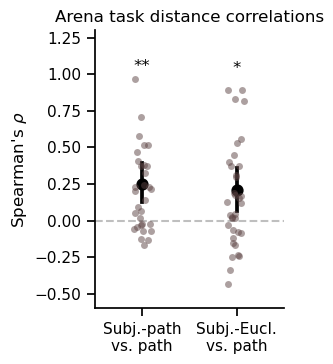

In [36]:
# Correlation method
corr_method = "spearman"

# Compute correlation DataFrames for subjective path distances
subj_path_corrs = pd.concat([
    get_corr_df(mm4_dt_unc, "1", key1="subj_spd_m_flat", key2="spd_m_flat", corr_method=corr_method),
], ignore_index=True)

# Compute correlation DataFrames for subjective Euclidean distances
subj_eucl_corrs = pd.concat([
    get_corr_df(mm4_dt_unc, "1", key1="subj_eucd_m_flat", key2="spd_m_flat", corr_method=corr_method),
], ignore_index=True)

# Ensure 'var_type' column is numeric
subj_path_corrs['var_type'] = pd.to_numeric(subj_path_corrs['var_type'], errors='coerce')
subj_eucl_corrs['var_type'] = pd.to_numeric(subj_eucl_corrs['var_type'], errors='coerce')

# Shift var_type for Euclidean correlations so categories don’t overlap
subj_eucl_corrs["var_type"] += 2

# Combine both DataFrames
all_corrs = pd.concat([subj_path_corrs, subj_eucl_corrs])

# Plot setup
fig, ax = plt.subplots(1, 1, figsize=(3.1, 3.8))
ax.axhline(y=0.0, color="grey", linestyle="--", alpha=0.5)

# Plot mean + data points
sns.pointplot(all_corrs, x="var_type", y="subj_corr", color="black",
              estimator=spa.fisher_mean_r,
              n_boot=5000, dodge=True,
              alpha=0.99, linestyle="none", ax=ax)
sns.stripplot(all_corrs, x="var_type", y="subj_corr", color=dark_brown_palette[0],
              alpha=0.5, ax=ax)

ax.set_ylim([-0.6, 1.3])

# Define x-axis labels
tick_labels = [
    "Subj.-path\nvs. path",
    "Subj.-Eucl.\nvs. path",
]
ax.set_xticks(range(2))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("")
ax.set_ylabel(r"Spearman's $\rho$")

# === Significance tests against 0 correlation ===
corrs_1 = all_corrs.query('var_type == 1')['subj_corr']
corrs_3 = all_corrs.query('var_type == 3')['subj_corr']
z_corrs_1 = spa.fisher_z(corrs_1)
z_corrs_3 = spa.fisher_z(corrs_3)
print("1 normality:", pg.normality(z_corrs_1)[["pval", "normal"]].iloc[0].tolist())
print("2 normality:", pg.normality(z_corrs_3)[["pval", "normal"]].iloc[0].tolist())

ttest_subj_path_vs_path = pg.ttest(z_corrs_1, 0)
ttest_subj_eucl_vs_path = pg.ttest(z_corrs_3, 0)

pval_subj_path_vs_path = ttest_subj_path_vs_path["p-val"].iloc[0]
pval_subj_eucl_vs_path = ttest_subj_eucl_vs_path["p-val"].iloc[0]

mean_1 = spa.fisher_mean_r(corrs_1)
mean_3 = spa.fisher_mean_r(corrs_3)

print(rf'1: ρ={mean_1:.2f}, '
      rf'95% CI {ttest_subj_path_vs_path["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_path_vs_path["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_path_vs_path)}')
print(rf'3: ρ={mean_3:.2f}, '
      rf'95% CI {ttest_subj_eucl_vs_path["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_eucl_vs_path["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_eucl_vs_path)}')

sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_path), 0, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_eucl_vs_path), 1, 1.05, ax=ax)

# Finalize figure
ax.set_title("Arena task distance correlations")
fig.tight_layout()

In [37]:
avg_rand_eucd_m = np.round(task4_dt_unc["avg_rand_eucd_m"].iloc[0], 7)
avg_rand_eucd_m -= avg_rand_eucd_m.min()  # make zero diagonal
avg_rand_eucd_flat = sgu.get_upper_triangle_without_diagonal(avg_rand_eucd_m)

/tmp/ipykernel_3474219/2040056566.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(all_corrs, x="var_type", y="subj_corr",
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pingouin/parametric.py:243: RuntimeWarning: Degrees of freedom <= 0 for slice
  se = np.sqrt(x.var(ddof=1) / nx)
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in di

01: ρ=nan, 95% CI [nan nan], T=nan, p = nan
02: ρ=0.53, 95% CI [0.3  0.55], T=6.80, p < .001
1: ρ=0.25, 95% CI [0.1  0.31], T=4.15, p < .001
2: ρ=0.13, 95% CI [0.03 0.2 ], T=2.65, p = 0.012
3: ρ=0.21, 95% CI [0.04 0.28], T=2.69, p = 0.011
4: ρ=0.14, 95% CI [0.06 0.21], T=3.70, p < .001
Normality check 02: False
Difference (01 vs 02):                T  dof alternative     p-val         CI95%   cohen-d    BF10  \
T-test  3.702171   34   two-sided  0.000753  [0.06, 0.21]  0.625781  40.829   

           power  
T-test  0.949054  
Normality check 1: False
Normality check 2: False
Difference (1 vs 2):                T        dof alternative     p-val          CI95%   cohen-d  \
T-test  1.458518  50.163291   two-sided  0.150931  [-0.05, 0.31]  0.368982   

        BF10     power  
T-test  0.62  0.313665  
Normality check 3: False
Normality check 4: True
Difference (3 vs 4):                T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test  0.822718   68   two-sided  0.4135

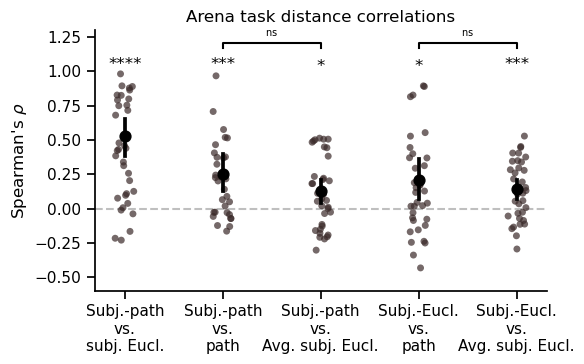

In [43]:
# Correlation method
corr_method = "spearman"

subj_subj_corrs = pd.concat([
    # get_corr_df(mm4_dt_rot, "01", key1="subj_spd_m_flat", key2="subj_eucd_m_flat", corr_method=corr_method),
    get_corr_df(mm4_dt_unc, "02", key1="subj_spd_m_flat", key2="subj_eucd_m_flat", corr_method=corr_method)
])

# Compute correlation DataFrames for subjective path distances
subj_path_corrs = pd.concat([
    get_corr_df(mm4_dt_unc, "1", key1="subj_spd_m_flat", key2="spd_m_flat", corr_method=corr_method),
#     get_corr_df(mm4_dt_unc, "2", key1="subj_spd_m_flat", key2="avg_rand_eucd_m_flat", corr_method=corr_method)
    get_corr_df(mm4_dt_unc, "2", key1="subj_spd_m_flat", key2="avg_subj_eucd_m_flat", corr_method=corr_method)
], ignore_index=True)

# Compute correlation DataFrames for subjective Euclidean distances
subj_eucl_corrs = pd.concat([
    get_corr_df(mm4_dt_unc, "1", key1="subj_eucd_m_flat", key2="spd_m_flat", corr_method=corr_method),
#     get_corr_df(mm4_dt_unc, "2", key1="subj_eucd_m_flat", key2="avg_rand_eucd_m_flat", corr_method=corr_method)
    get_corr_df(mm4_dt_unc, "2", key1="subj_eucd_m_flat", key2="avg_subj_eucd_m_flat", corr_method=corr_method)
], ignore_index=True)

# Ensure 'var_type' column is numeric
subj_path_corrs['var_type'] = pd.to_numeric(subj_path_corrs['var_type'], errors='coerce')
subj_eucl_corrs['var_type'] = pd.to_numeric(subj_eucl_corrs['var_type'], errors='coerce')

# Shift var_type for Euclidean correlations so categories don’t overlap
subj_eucl_corrs["var_type"] += 2

# Combine both DataFrames
all_corrs = pd.concat([subj_subj_corrs, subj_path_corrs, subj_eucl_corrs])

# Plot setup
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.8))
ax.axhline(y=0.0, color="grey", linestyle="--", alpha=0.5)

# Plot mean + data points
sns.pointplot(all_corrs, x="var_type", y="subj_corr", color="black",
              estimator=spa.fisher_mean_r,
              n_boot=5000, zorder=9,
              alpha=0.99, linestyle="none", ax=ax)
sns.stripplot(all_corrs, x="var_type", y="subj_corr", 
              palette=[
                    "#3A2A29",
                    "#3A2A29",
                    "#3A2A29",
                    "#3A2A29",
                    "#3A2A29",
                    ],  
              alpha=0.7, ax=ax,
              )

# ax.set_ylim([-0.5, 1.7])
ax.set_ylim([-0.6, 1.3])

# Define x-axis labels
tick_labels = [
    # "Subj.-path\nvs.\nsubj. Eucl.",
    "Subj.-path\nvs.\nsubj. Eucl.",
    "Subj.-path\nvs.\npath",
#     "Subj.-path\nvs.\nAvg. rand. Eucl.",
    "Subj.-path\nvs.\nAvg. subj. Eucl.",
    "Subj.-Eucl.\nvs.\npath",
#     "Subj.-Eucl.\nvs.\nAvg. rand. Eucl."
    "Subj.-Eucl.\nvs.\nAvg. subj. Eucl."
]
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("")
ax.set_ylabel(r"Spearman's $\rho$")

# === Significance tests against 0 correlation ===
ttest_subj_path_vs_subj_eucl_1 = pg.ttest(all_corrs.query("var_type == '01'")["subj_corr"], 0)
ttest_subj_path_vs_subj_eucl_2 = pg.ttest(all_corrs.query("var_type == '02'")["subj_corr"], 0)
ttest_subj_path_vs_path = pg.ttest(all_corrs.query("var_type == 1")["subj_corr"], 0)
ttest_subj_path_vs_eucl = pg.ttest(all_corrs.query("var_type == 2")["subj_corr"], 0)
ttest_subj_eucl_vs_path = pg.ttest(all_corrs.query("var_type == 3")["subj_corr"], 0)
ttest_subj_eucl_vs_eucl = pg.ttest(all_corrs.query("var_type == 4")["subj_corr"], 0)

pval_subj_path_vs_subj_eucl_1 = ttest_subj_path_vs_subj_eucl_1["p-val"].iloc[0]
pval_subj_path_vs_subj_eucl_2 = ttest_subj_path_vs_subj_eucl_2["p-val"].iloc[0]
pval_subj_path_vs_path = ttest_subj_path_vs_path["p-val"].iloc[0]
pval_subj_path_vs_eucl = ttest_subj_path_vs_eucl["p-val"].iloc[0]
pval_subj_eucl_vs_path = ttest_subj_eucl_vs_path["p-val"].iloc[0]
pval_subj_eucl_vs_eucl = ttest_subj_eucl_vs_eucl["p-val"].iloc[0]

mean_01 = spa.fisher_mean_r(all_corrs.query('var_type == "01"')['subj_corr'])
mean_02 = spa.fisher_mean_r(all_corrs.query('var_type == "02"')['subj_corr'])
mean_1 = spa.fisher_mean_r(all_corrs.query('var_type == 1')['subj_corr'])
mean_2 = spa.fisher_mean_r(all_corrs.query('var_type == 2')['subj_corr'])
mean_3 = spa.fisher_mean_r(all_corrs.query('var_type == 3')['subj_corr'])
mean_4 = spa.fisher_mean_r(all_corrs.query('var_type == 4')['subj_corr'])

print(rf'01: ρ={mean_01:.2f}, 95% CI {ttest_subj_path_vs_subj_eucl_1["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_path_vs_subj_eucl_1["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_path_vs_subj_eucl_1)}')
print(rf'02: ρ={mean_02:.2f}, 95% CI {ttest_subj_path_vs_subj_eucl_2["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_path_vs_subj_eucl_2["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_path_vs_subj_eucl_2)}')
print(rf'1: ρ={mean_1:.2f}, 95% CI {ttest_subj_path_vs_path["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_path_vs_path["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_path_vs_path)}')
print(rf'2: ρ={mean_2:.2f}, 95% CI {ttest_subj_path_vs_eucl["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_path_vs_eucl["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_path_vs_eucl)}')
print(rf'3: ρ={mean_3:.2f}, 95% CI {ttest_subj_eucl_vs_path["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_eucl_vs_path["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_eucl_vs_path)}')
print(rf'4: ρ={mean_4:.2f}, 95% CI {ttest_subj_eucl_vs_eucl["CI95%"].iloc[0]}, '
      rf'T={ttest_subj_eucl_vs_eucl["T"].iloc[0]:.2f}, {stu.format_p(pval_subj_eucl_vs_eucl)}')

# sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_subj_eucl_1), 0, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_subj_eucl_2), 0, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_path), 1, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_eucl), 2, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_eucl_vs_path), 3, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_eucl_vs_eucl), 4, 1.05, ax=ax)

# === Group comparisons ===
# Subj.-path vs path  vs  subj.-path vs Eucl. (Fisher z transform)
# corrs_01 = ssu.fisher_z(all_corrs.query("var_type == '01'")['subj_corr'])
corrs_02 = ssu.fisher_z(all_corrs.query("var_type == '02'")['subj_corr'])

# ttest_subj = pg.ttest(corrs_01, corrs_02)
# print(f"Normality check 01: {pg.normality(corrs_01)['normal'].iloc[0]}")
print(f"Normality check 02: {pg.normality(corrs_02)['normal'].iloc[0]}")
print("Difference (01 vs 02):", ttest_subj_eucl_vs_eucl)

# sap.annot_stat(sap.calc_stars(ttest_subj["p-val"].iloc[0], near_to=True), 0, 1, 1.17, ax=ax)

corrs_1 = ssu.fisher_z(all_corrs.query("var_type == 1")['subj_corr'])
corrs_2 = ssu.fisher_z(all_corrs.query("var_type == 2")['subj_corr'])

ttest_path = pg.ttest(corrs_1, corrs_2)
print(f"Normality check 1: {pg.normality(corrs_1)['normal'].iloc[0]}")
print(f"Normality check 2: {pg.normality(corrs_2)['normal'].iloc[0]}")
print("Difference (1 vs 2):", ttest_path)

# sap.annot_stat(sap.calc_stars(ttest_path["p-val"].iloc[0], near_to=True), 2, 3, 1.17, ax=ax)

# Subj.-Eucl. vs path  vs  subj.-Eucl. vs Eucl. (Fisher z transform)
corr_3 = ssu.fisher_z(all_corrs.query("var_type == 3")['subj_corr'])
corr_4 = ssu.fisher_z(all_corrs.query("var_type == 4")['subj_corr'])

ttest_eucl = pg.ttest(corr_3, corr_4)

print(f"Normality check 3: {pg.normality(corr_3)['normal'].iloc[0]}")
print(f"Normality check 4: {pg.normality(corr_4)['normal'].iloc[0]}")
print("Difference (3 vs 4):", ttest_eucl)

# sap.annot_stat(sap.calc_stars(ttest_eucl["p-val"].iloc[0], near_to=True), 4, 5, 1.17, ax=ax)

# # Cross comparisons
ttest_3vs4 = pg.ttest(corr_3, corr_4, correction="auto")
ttest_1vs2 = pg.ttest(corrs_1, corrs_2, correction="auto")

print("Difference (3 vs 4):", ttest_3vs4)
print("Difference (1 vs 2):", ttest_1vs2)

sap.annot_stat(sap.calc_stars(ttest_1vs2["p-val"].iloc[0], near_to=True), 1, 2, 1.17, ax=ax)
sap.annot_stat(sap.calc_stars(ttest_3vs4["p-val"].iloc[0], near_to=True), 3, 4, 1.17, ax=ax)

# Finalize figure
ax.set_title("Arena task distance correlations")
fig.tight_layout()

In [44]:
pg.ttest(corrs_1, corr_3)
# ttest_1vs3

# ttest_1vs3 = pg.ttest(corrs_1, corr_3)#, correction="auto")
# ttest_1vs3

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.376511,63.974355,two-sided,0.707783,"[-0.18, 0.26]",0.092275,0.268,0.065701


In [45]:
all_corrs_1 = all_corrs.query("var_type == 1")
all_corrs_3 = all_corrs.query("var_type == 3")
all_corrs_3 = all_corrs_3[all_corrs_3["subject_id"].isin(all_corrs_1.subject_id)]

pg.ttest(all_corrs_1["subj_corr"], all_corrs_3["subj_corr"])

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.673845,60,two-sided,0.099367,"[-0.02, 0.26]",0.425157,0.834,0.377332


In [46]:
task4_dt["avg_rand_eucd_m"] = task4_dt["avg_rand_eucd_m"].apply(lambda r: r - r.min())

avg_rand_eucd_m = np.round(task4_dt_unc["avg_rand_eucd_m"].iloc[0], 7)
avg_rand_eucd_m -= avg_rand_eucd_m.min()  # make zero diagonal
avg_rand_eucd_flat = sgu.get_upper_triangle_without_diagonal(avg_rand_eucd_m)

## Correlation between subjective distances

In [47]:
# Compute correlation DataFrames for subjective Euclidean distances
subj_eucl_corrs_unc = pd.concat([
    get_corr_df(mm4_dt_unc, "1", key1="subj_eucd_m_flat", key2="spd_m_flat", corr_method=corr_method),
], ignore_index=True)

subj_eucl_corrs_rot = pd.concat([
    get_corr_df(mm4_dt_rot, "1", key1="subj_eucd_m_flat", key2="spd_m_flat", corr_method=corr_method),
], ignore_index=True)

pg.ttest(ssu.fisher_z(subj_eucl_corrs_rot["subj_corr"]), ssu.fisher_z(subj_eucl_corrs_unc["subj_corr"]))
# pg.mwu(ssu.fisher_z(subj_eucl_corrs_rot["subj_corr"]), ssu.fisher_z(subj_eucl_corrs_unc["subj_corr"]))
# pg.normality(ssu.fisher_z(subj_eucl_corrs_rot["subj_corr"]))
# pg.normality(ssu.fisher_z(subj_eucl_corrs_unc["subj_corr"]))

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.02786,65.501726,two-sided,0.307796,"[-0.32, 0.1]",0.248313,0.391,0.17219


Exp. 1: ρ=0.35, 95% CI [0.13 0.6 ], T=3.14, p = 0.004
Exp. 2: ρ=0.53, 95% CI [0.38 0.79], T=5.81, p < .001
               T        dof alternative     p-val          CI95%   cohen-d  \
T-test -1.465722  64.325859   two-sided  0.147595  [-0.53, 0.08]  0.356728   

         BF10     power  
T-test  0.619  0.304952  


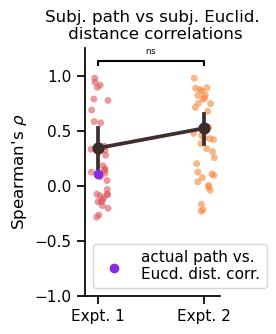

In [51]:
subj_corr_df = pd.concat([
    get_corr_df(mm4_dt_rot, "rotational", corr_method=corr_method),
    get_corr_df(mm4_dt_unc, "unconstrained", corr_method=corr_method)
], ignore_index=True)

spd_m_flat = task3_4_dt["spd_m_flat"].iloc[0]
eucd_m_flat = task3_4_dt["eucd_m_flat"].iloc[0]

exp_1_dt = subj_corr_df.query("var_type == 'rotational'")["subj_corr"]
exp_2_dt = subj_corr_df.query("var_type == 'unconstrained'")["subj_corr"]

ttest_exp_1 = pg.ttest(spa.fisher_z(exp_1_dt), 0)
ttest_exp_2 = pg.ttest(spa.fisher_z(exp_2_dt), 0)
print(rf'Exp. 1: ρ={spa.fisher_mean_r(exp_1_dt):.2f}, '
      rf'95% CI {ttest_exp_1["CI95%"].iloc[0]}, '
      rf'T={ttest_exp_1["T"].iloc[0]:.2f}, {stu.format_p(ttest_exp_1["p-val"].iloc[0])}')
print(rf'Exp. 2: ρ={spa.fisher_mean_r(exp_2_dt):.2f}, '
      rf'95% CI {ttest_exp_2["CI95%"].iloc[0]}, '
      rf'T={ttest_exp_2["T"].iloc[0]:.2f}, {stu.format_p(ttest_exp_2["p-val"].iloc[0])}')

fig, axs = plt.subplots(1,1, figsize=(2.5,3.5))

spa.axplot_corrs_by_subj(subj_corr_df, ax=axs)
axs.set_title("Subj. path vs subj. Euclid.\n distance correlations")

true_corr = ssu.calc_correlation(
    task4_dt.iloc[0]["spd_m_flat"], 
    task4_dt.iloc[0]["eucd_m_flat"], method=corr_method)[0]
axs.scatter(0.0, true_corr, color="blueviolet", label="actual path vs.\nEucd. dist. corr.", zorder=20)

axs.set_xticks([0, 1])
axs.set_xticklabels(["Expt. 1", "Expt. 2"])

axs.legend()
fig.tight_layout()

In [52]:
# ttest = pg.ttest(spd_corr_df["subj_corr"], 0)
# stu.stat_report(ttest)

In [53]:
# ttest = pg.ttest(eucd_corr_df["subj_corr"], 0)
# stu.stat_report(ttest)

## Panel f: Choice prediction from true and subjective distances

In [54]:
task3_4_unc = task3_4_dt.query("var_type == 'unconstrained'")
mm3_unc = smm.prepare_mm3_dt(task3_4_unc, zscore_flag=True)

### Model 1

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2861	 Groups: {'subject_id': 43.0}

Log-likelihood: -1956.510 	 AIC: 3921.020

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.058  0.242

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


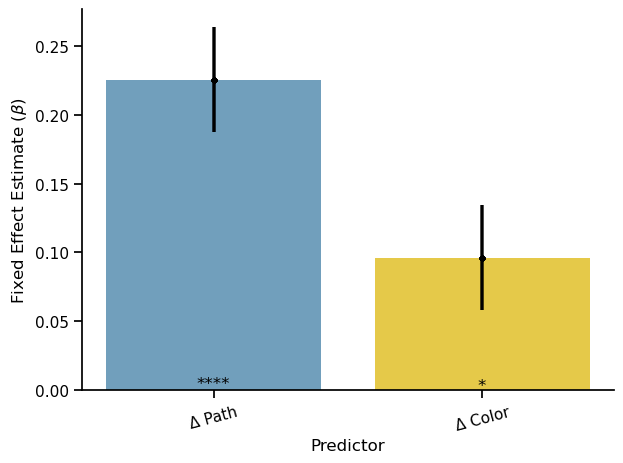

Corr. of true and gen data: spearm=0.19, p_val=0.0000


In [55]:
true_predictors = [
    'spd_pp_diff', 
    "color_pp_diff",
]
dt = mm3_unc.copy()
 
model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, interaction=False, rand_slope=False,
    skip_eucd=False,
    )

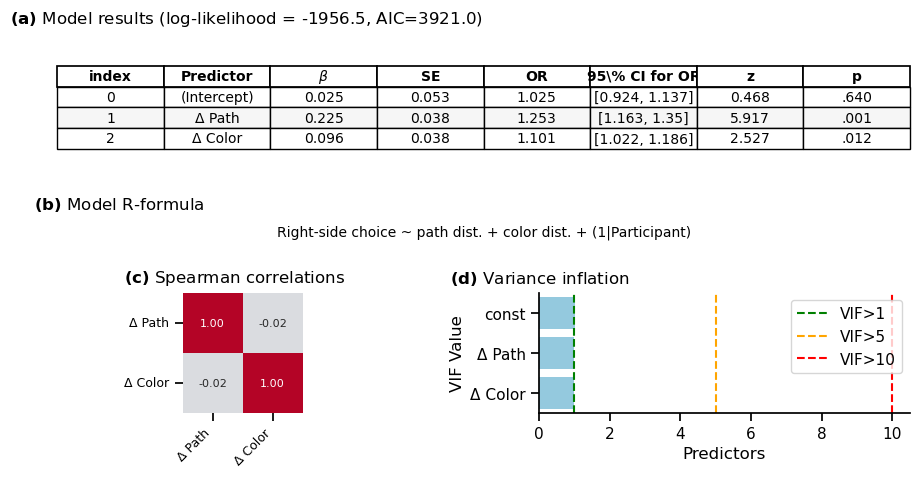

In [57]:
fig = smm.plot_model_specs(dt, results_true, model_true, height_ratios=[1.2, 0.35, 1], fig_size=(11, 4.9))
plt.show()

In [58]:
res = results_true
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.03 & 0.05 & 0.47 & .640 & 1.02 & [0.924, 1.137] \\
$\Delta$ Path & 0.23 & 0.04 & 5.92 & .001 & 1.25 & [1.163, 1.35] \\
$\Delta$ Color & 0.10 & 0.04 & 2.53 & .012 & 1.10 & [1.022, 1.186] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.000 \\
\makecell[l]{$\Delta$ Color} & 1.000 \\
\hline
\end{tabular}
\end{table}


### Model 4

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2276	 Groups: {'subject_id': 35.0}

Log-likelihood: -1552.381 	 AIC: 3112.762

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.022  0.149

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


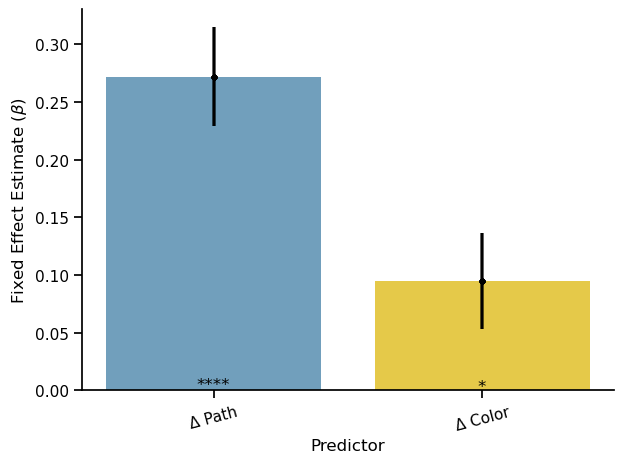

Corr. of true and gen data: spearm=0.18, p_val=0.0000


In [59]:
true_predictors = [
    'spd_pp_diff', 
    "color_pp_diff",
]
dt = mm3_unc[~mm3_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()
 
model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, interaction=False, rand_slope=False,
    skip_eucd=False,
    )

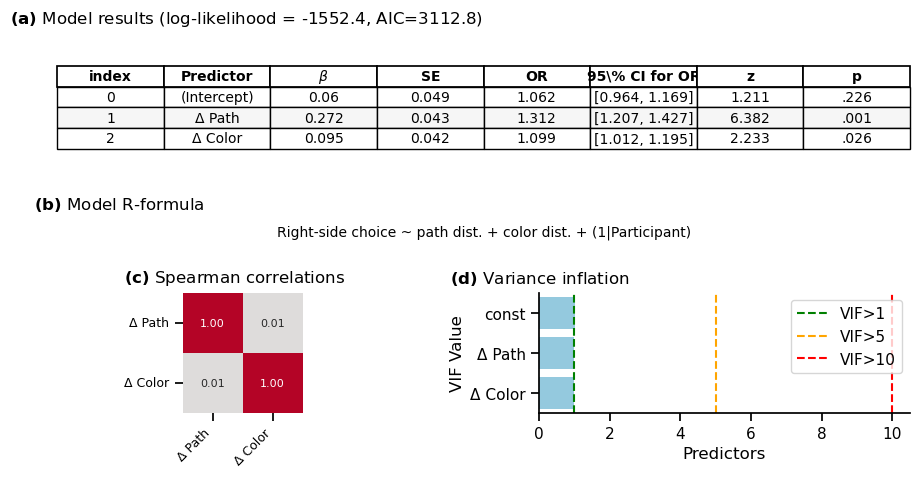

In [60]:
fig = smm.plot_model_specs(dt, results_true, model_true, height_ratios=[1.2, 0.35, 1], fig_size=(11, 4.9))
plt.show()

In [61]:
res = results_true
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.06 & 0.05 & 1.21 & .226 & 1.06 & [0.964, 1.169] \\
$\Delta$ Path & 0.27 & 0.04 & 6.38 & .001 & 1.31 & [1.207, 1.427] \\
$\Delta$ Color & 0.10 & 0.04 & 2.23 & .026 & 1.10 & [1.012, 1.195] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.000 \\
\makecell[l]{$\Delta$ Color} & 1.000 \\
\hline
\end{tabular}
\end{table}


### Model 3

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+color_pp_diff+avg_learn_eucd_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2861	 Groups: {'subject_id': 43.0}

Log-likelihood: -1948.322 	 AIC: 3906.645

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.058  0.241

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


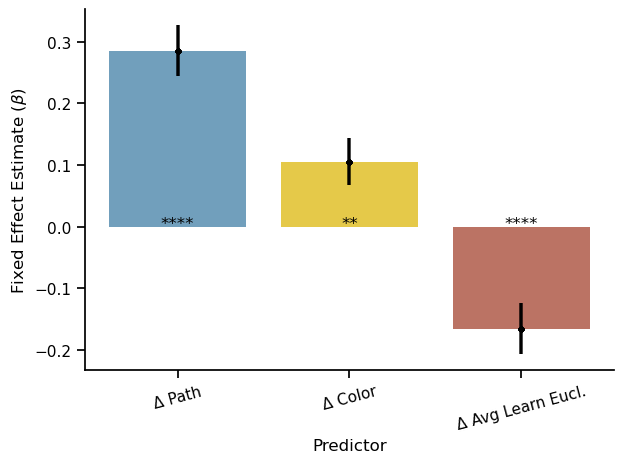

Corr. of true and gen data: spearm=0.20, p_val=0.0000


In [62]:
true_predictors = [
    'spd_pp_diff', 
    "color_pp_diff",
    "avg_learn_eucd_pp_diff",
]
dt = mm3_unc.copy()
 
model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, interaction=False, rand_slope=False,
    skip_eucd=False,
    )

In [63]:
icc = smm.icc_from_pymer(model_true)
print("ICC:", icc)

ICC: [0.04146358]


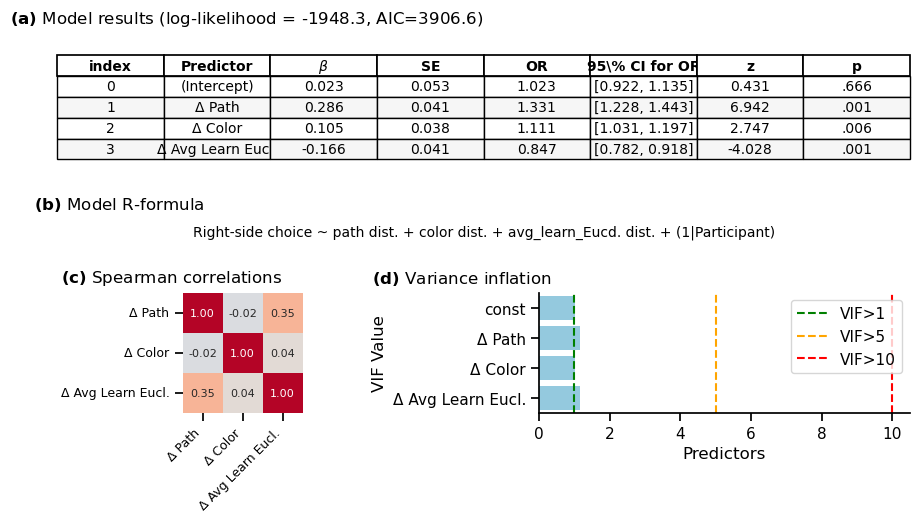

In [64]:
fig = smm.plot_model_specs(dt, results_true, model_true, height_ratios=[1.2, 0.35, 1], fig_size=(11, 4.9))
plt.show()

In [65]:
res = results_true
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.02 & 0.05 & 0.43 & .666 & 1.02 & [0.922, 1.135] \\
$\Delta$ Path & 0.29 & 0.04 & 6.94 & .001 & 1.33 & [1.228, 1.443] \\
$\Delta$ Color & 0.10 & 0.04 & 2.75 & .006 & 1.11 & [1.031, 1.197] \\
$\Delta$ Avg Learn Eucl. & -0.17 & 0.04 & -4.03 & .001 & 0.85 & [0.782, 0.918] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.145 \\
\makecell[l]{$\Delta$ Color} & 1.003 \\
\makecell[l]{$\Delta$ Avg Learn Eucl.} & 1.147 \\
\hline
\end{tabular}
\end{table}


### Model 2

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~color_pp_diff+avg_learn_eucd_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2861	 Groups: {'subject_id': 43.0}

Log-likelihood: -1972.784 	 AIC: 3953.567

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.059  0.243

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


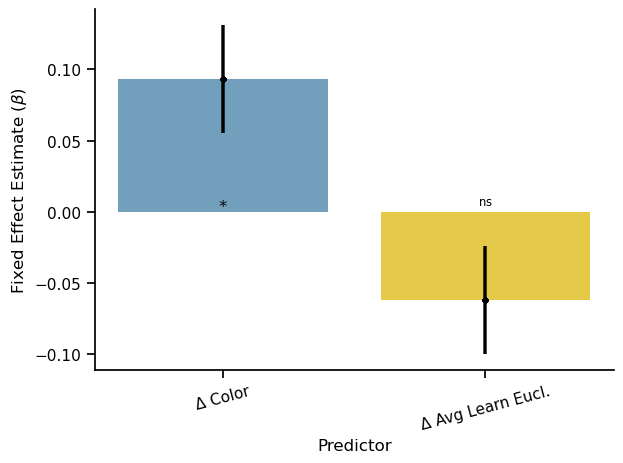

Corr. of true and gen data: spearm=0.16, p_val=0.0000


In [66]:
true_predictors = [
    "color_pp_diff",
    "avg_learn_eucd_pp_diff",
]
dt = mm3_unc.copy()
 
model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, interaction=False, rand_slope=False,
    skip_eucd=False,
    )

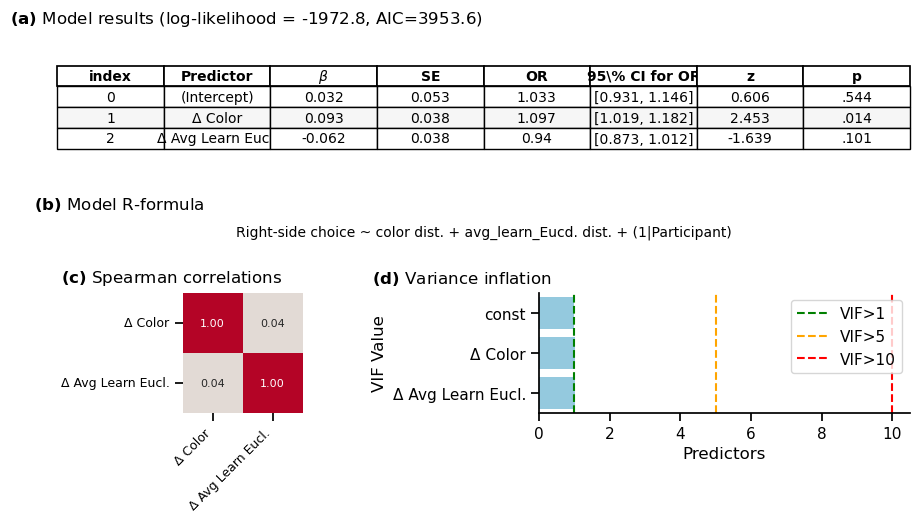

In [67]:
fig = smm.plot_model_specs(dt, results_true, model_true, height_ratios=[1.2, 0.35, 1], fig_size=(11, 4.9))
plt.show()

In [68]:
res = results_true
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.03 & 0.05 & 0.61 & .544 & 1.03 & [0.931, 1.146] \\
$\Delta$ Color & 0.09 & 0.04 & 2.45 & .014 & 1.10 & [1.019, 1.182] \\
$\Delta$ Avg Learn Eucl. & -0.06 & 0.04 & -1.64 & .101 & 0.94 & [0.873, 1.012] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Color} & 1.002 \\
\makecell[l]{$\Delta$ Avg Learn Eucl.} & 1.002 \\
\hline
\end{tabular}
\end{table}


### Model 5

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~subj_spd_pp_diff+subj_eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2276	 Groups: {'subject_id': 35.0}

Log-likelihood: -1545.039 	 AIC: 3100.078

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.022  0.149

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


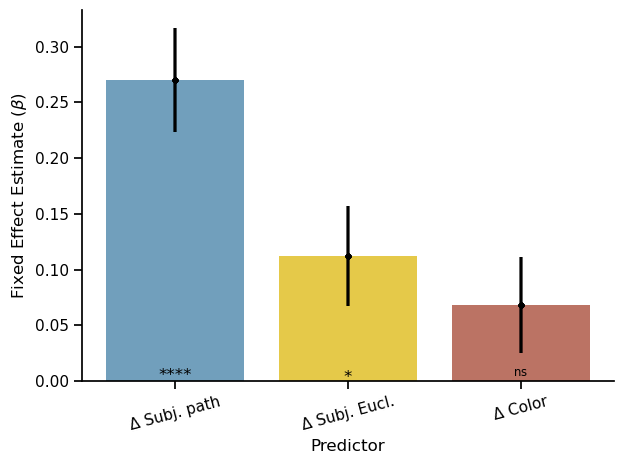

Corr. of true and gen data: spearm=0.22, p_val=0.0000


In [69]:
subj_predictors = [
    'subj_spd_pp_diff',
    'subj_eucd_pp_diff',
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_unc[~mm3_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()

# Recenter and rescale
pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff") and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

model_subj, results_subj = smm.run_mixed_model(
    dt, subj_predictors, plotting=1,
    )

In [70]:
results_subj

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.070,-0.027,0.168,0.050,1.073,0.974,1.182,0.518,0.493,0.542,1.422,0.155,
subj_spd_pp_diff,0.270,0.178,0.362,0.047,1.310,1.195,1.436,0.567,0.544,0.589,5.766,0.000,***
subj_eucd_pp_diff,0.112,0.023,0.201,0.045,1.119,1.024,1.223,0.528,0.506,0.550,2.476,0.013,*
color_pp_diff,0.069,-0.016,0.153,0.043,1.071,0.985,1.165,0.517,0.496,0.538,1.598,0.110,


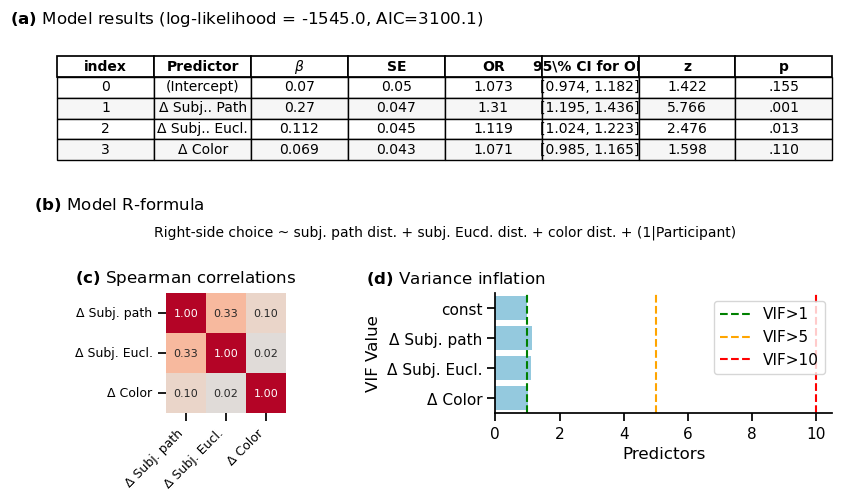

In [71]:
fig = smm.plot_model_specs(dt, results_subj, model_subj, height_ratios=[1.2, 0.35, 1], fig_size=(10, 4.9))
plt.show()

In [72]:
res = results_subj
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.07 & 0.05 & 1.42 & .155 & 1.07 & [0.974, 1.182] \\
$\Delta$ Subj. path & 0.27 & 0.05 & 5.77 & .001 & 1.31 & [1.195, 1.436] \\
$\Delta$ Subj. Eucl. & 0.11 & 0.04 & 2.48 & .013 & 1.12 & [1.024, 1.223] \\
$\Delta$ Color & 0.07 & 0.04 & 1.60 & .110 & 1.07 & [0.985, 1.165] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Subj. path} & 1.132 \\
\makecell[l]{$\Delta$ Subj. Eucl.} & 1.120 \\
\makecell[l]{$\Delta$ Color} & 1.011 \\
\hline
\end{tabular}
\end{table}


### Model 6

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+subj_spd_pp_diff+subj_eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2276	 Groups: {'subject_id': 35.0}

Log-likelihood: -1531.529 	 AIC: 3075.057

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.024  0.155

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


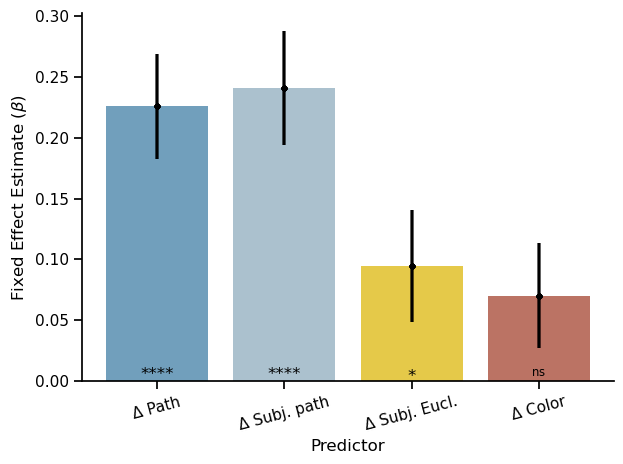

Corr. of true and gen data: spearm=0.23, p_val=0.0000


In [73]:
subj_predictors = [
    'spd_pp_diff', 
    'subj_spd_pp_diff',
    'subj_eucd_pp_diff',
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_unc[~mm3_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()

# Recenter and rescale
pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff") and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

model_subj, results_subj = smm.run_mixed_model(
    dt, subj_predictors, plotting=1, rand_slope=False,
    bootstrap=False,
    )

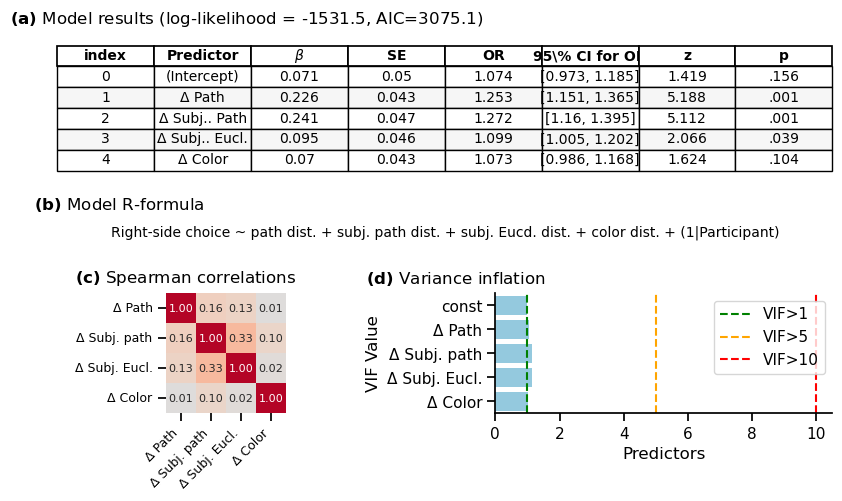

In [74]:
fig = smm.plot_model_specs(dt, results_subj, model_subj, height_ratios=[1.2, 0.35, 1], fig_size=(10, 4.9))
plt.show()

In [75]:
res = results_subj
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.07 & 0.05 & 1.42 & .156 & 1.07 & [0.973, 1.185] \\
$\Delta$ Path & 0.23 & 0.04 & 5.19 & .001 & 1.25 & [1.151, 1.365] \\
$\Delta$ Subj. path & 0.24 & 0.05 & 5.11 & .001 & 1.27 & [1.16, 1.395] \\
$\Delta$ Subj. Eucl. & 0.10 & 0.05 & 2.07 & .039 & 1.10 & [1.005, 1.202] \\
$\Delta$ Color & 0.07 & 0.04 & 1.62 & .104 & 1.07 & [0.986, 1.168] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.034 \\
\makecell[l]{$\Delta$ Subj. path} & 1.150 \\
\makecell[l]{$\Delta$ Subj. Eucl.} & 1.128 \\
\makecell[l]{$\Delta$ Color} & 1.011 \\
\hline
\end{tabular}
\end{table}


### Model 7

/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~avg_subj_spd_pp_diff+subj_spd_subt_pp_diff+avg_subj_eucd_pp_diff+subj_eucd_subt_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2276	 Groups: {'subject_id': 35.0}

Log-likelihood: -1537.855 	 AIC: 3089.711

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.021  0.144

No random effect correlations specified

Fixed effects:



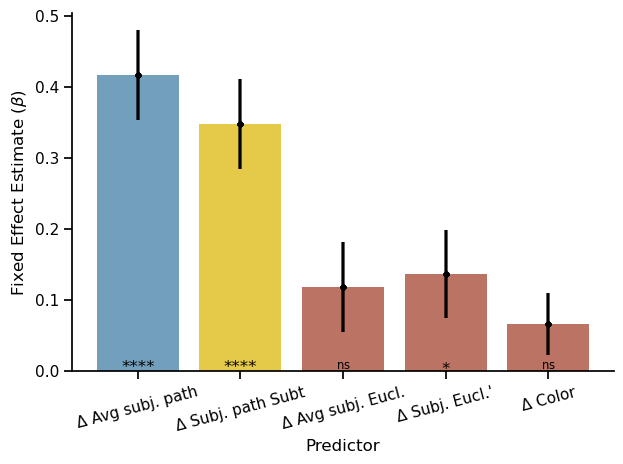

Corr. of true and gen data: spearm=0.22, p_val=0.0000


In [76]:
subj_predictors = [
    "avg_subj_spd_pp_diff",
    'subj_spd_subt_pp_diff',
    "avg_subj_eucd_pp_diff",
    "subj_eucd_subt_pp_diff",
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_unc[~mm3_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()
dt = dt.reset_index(drop=True)

# Recenter and rescale
pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff")]# and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

dt["subj_spd_subt_pp_diff"] = dt["subj_spd_pp_diff"] - dt["avg_subj_spd_pp_diff"]
dt["subj_eucd_subt_pp_diff"] = dt["subj_eucd_pp_diff"] - dt["avg_subj_eucd_pp_diff"]

# Recenter and rescale
pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff")]# and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

model_subj_avg, results_subj_avg = smm.run_mixed_model(
    dt, subj_predictors, plotting=1, rand_slope=False,
    )

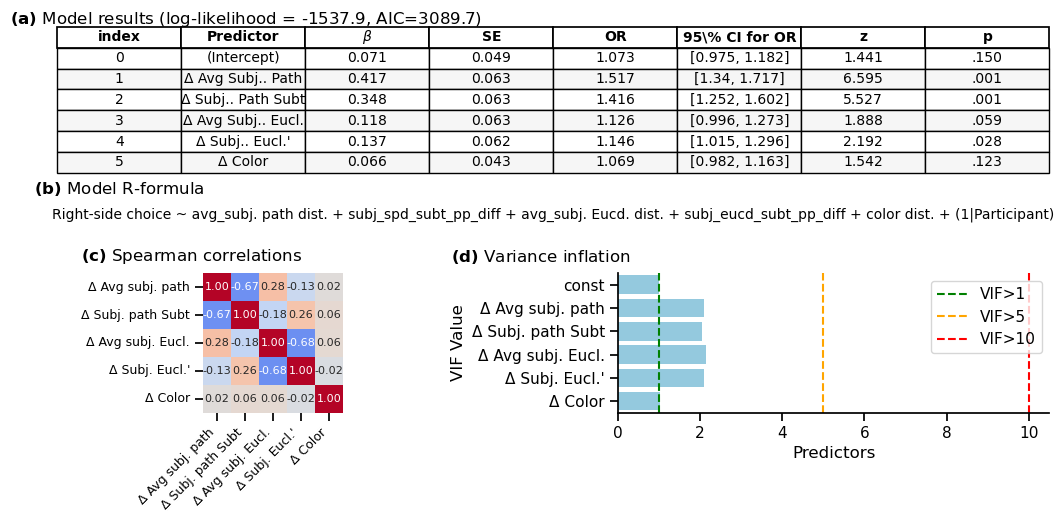

In [77]:
fig = smm.plot_model_specs(dt, results_subj_avg, model_subj_avg, height_ratios=[1.2, 0.35, 1.3], fig_size=(12.8, 4.9))
plt.show()

In [78]:
res = results_subj_avg
dt = dt
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & 0.07 & 0.05 & 1.44 & .150 & 1.07 & [0.975, 1.182] \\
$\Delta$ Avg subj. path & 0.42 & 0.06 & 6.59 & .001 & 1.52 & [1.34, 1.717] \\
$\Delta$ Subj. path Subt & 0.35 & 0.06 & 5.53 & .001 & 1.42 & [1.252, 1.602] \\
$\Delta$ Avg subj. Eucl. & 0.12 & 0.06 & 1.89 & .059 & 1.13 & [0.996, 1.273] \\
$\Delta$ Subj. Eucl.' & 0.14 & 0.06 & 2.19 & .028 & 1.15 & [1.015, 1.296] \\
$\Delta$ Color & 0.07 & 0.04 & 1.54 & .123 & 1.07 & [0.982, 1.163] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Avg subj. path} & 2.092 \\
\makecell[l]{$\Delta$ Subj. path Subt} & 2.053 \\
\makecell[l]{$\Delta$ Avg subj. Eucl.} & 2.135 \\
\makecell[l]{$\Delta$ Subj. Eucl.

## Supplementary 3

### All Predictor Correlations

In [79]:
dt = mm3_unc.copy()
dt = mm3_unc[~mm3_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()

dt["subj_spd_subt_pp_diff"] = dt["subj_spd_pp_diff"] - dt["avg_subj_spd_pp_diff"]
dt["subj_eucd_subt_pp_diff"] = dt["subj_eucd_pp_diff"] - dt["avg_subj_eucd_pp_diff"]
corr_m =  dt[[
    'spd_pp_diff',
    "avg_subj_spd_pp_diff",
    "subj_spd_pp_diff",
    "subj_spd_subt_pp_diff",
    "avg_subj_eucd_pp_diff",
    'subj_eucd_pp_diff',
    "subj_eucd_subt_pp_diff",
    "avg_learn_eucd_pp_diff",
    "color_pp_diff",
]].corr(method="spearman")

print(spa.corr_df_to_latex(corr_m))

\begin{table}[h!]
\centering
\scriptsize
\setlength{\tabcolsep}{2pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{lrrrrrrrrr}
\hline
 & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Avg subj. path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. path Subt}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Avg subj. Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. Eucl.'}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Avg Learn Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Color}} \\
\hline
$\Delta$ Path & 1.00 & 0.73 & 0.20 & -0.28 & 0.24 & 0.13 & -0.07 & 0.35 & 0.01 \\
$\Delta$ Avg subj. path & 0.73 & 1.00 & 0.13 & -0.52 & 0.26 & 0.09 & -0.13 & 0.34 & 0.01 \\
$\Delta$ Subj. path & 0.20 & 0.13 & 1.00 & 0.74 & 0.05 & 0.35 & 0.22 & 0

/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:631: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_fmt = df.applymap(_fmt)


<Axes: >

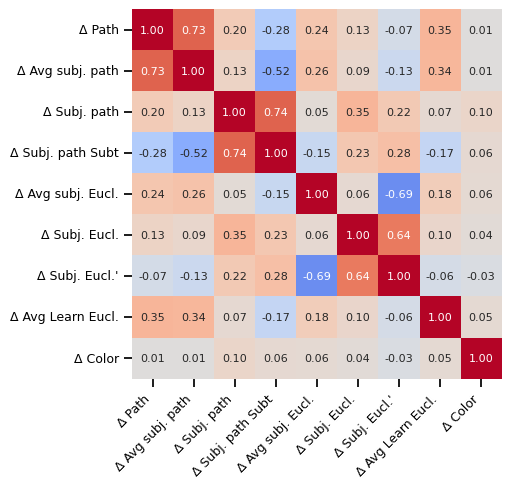

In [80]:
spa.axplot_heatmap(corr_m, labels=spa.format_labels(corr_m.columns))

## Panel e: Subj. distance predictions (Arena)

In [81]:
# Separate
task4_dt_rot = task4_dt[task4_dt["var_type"]=="rotational"]
task4_dt_unc = task4_dt[task4_dt["var_type"]=="unconstrained"]

subj_not_connect_rot = sad.subjects_not_connect(task3_4_dt_rot)
subj_not_connect_unc = sad.subjects_not_connect(task3_4_dt_unc)

task4_dt_rot = task4_dt_rot[~task4_dt_rot["subject_id"].isin(subj_not_connect_rot)]
task4_dt_unc = task4_dt_unc[~task4_dt_unc["subject_id"].isin(subj_not_connect_unc)]

mm4_dt_rot = smm.prepare_mm4_dt(task4_dt_rot)
mm4_dt_unc = smm.prepare_mm4_dt(task4_dt_unc)

### Model 2

/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


Linear mixed model fit by REML [’lmerMod’]
Formula: subj_eucd_m_flat~spd_m_flat+avg_subj_eucd_m_flat+color_m_flat+(1|subject_id)

Family: gaussian	 Inference: parametric

Number of observations: 980	 Groups: {'subject_id': 35.0}

Log-likelihood: -1269.812 	 AIC: 2551.623

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.284  0.533
Residual                 0.704  0.839

No random effect correlations specified

Fixed effects:

Corr. of true and gen data: spearm=0.55, p_val=0.0000


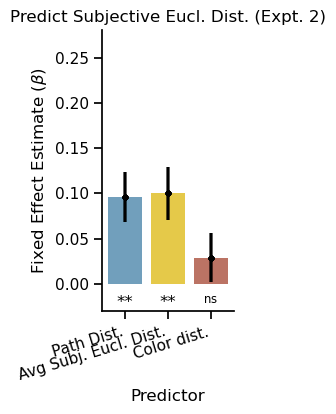

In [82]:
from pymer4.models import Lmer

pos_predictors = [
    'spd_m_flat', 
    'avg_subj_eucd_m_flat',
    'color_m_flat',
]

pred_str = [ f'{s}'for s in pos_predictors]
pred_str = " + ".join(pred_str)

m_cols = [c for c in mm4_dt_unc.columns if c.endswith("_m")]
for col in m_cols:
    mm4_dt_unc.loc[:, col] = sad.zscore(mm4_dt_unc[col])
response = "subj_eucd_m_flat"
model = Lmer(f'{response} ~ {pred_str} + (1|subject_id)', data=mm4_dt_unc, family="gaussian", )

results = model.fit()

fig, ax = plt.subplots(1,1, figsize=(2.4,4.3))
spa.axplot_fixed_effects(
    model.fixef, errors=results["SE"], p_vals=results["P-val"], 
    p_val_pos=-0.02, ax=ax, label_rotation=17,
    skip_eucd=False, skip_wspd=False,
    label_ha="right",
    )
ax.set_title("Predict Subjective Eucl. Dist. (Expt. 2)")
ax.set_ylim([-0.03, 0.28])
plt.tight_layout()

# Correlate gen data with true data
corr = scipy.stats.spearmanr(model.fits, mm4_dt_unc[response])
print(f"Corr. of true and gen data: spearm={corr[0]:.2f}, p_val={corr[1]:.4f}")

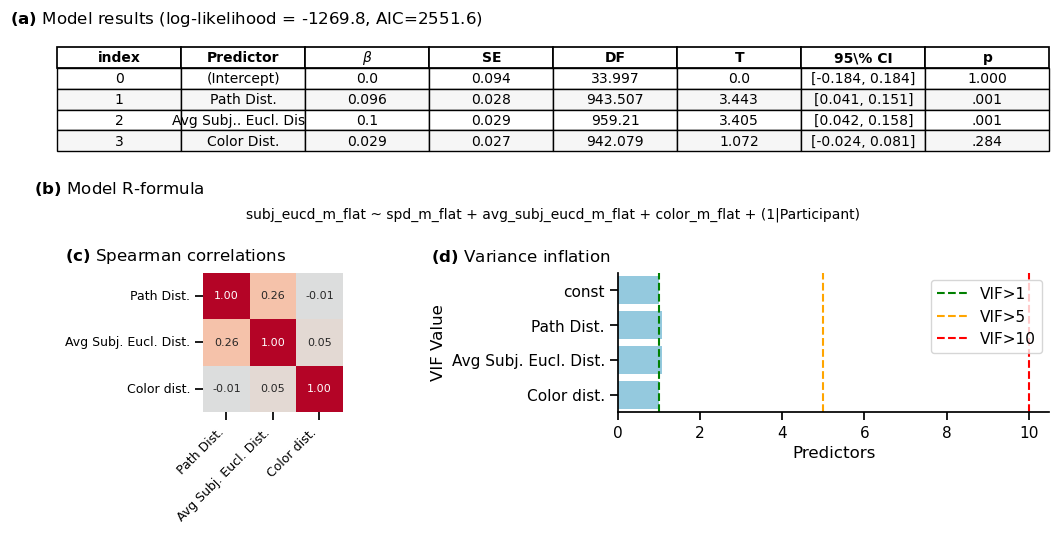

In [83]:
fig = smm.plot_model_specs(mm4_dt_unc, results, model, height_ratios=[1.2, 0.35, 1.3], fig_size=(12.8, 4.9))
plt.show()

In [84]:
res = results
dt = mm4_dt_unc
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrrll}
\hline
Predictor & $\beta$ & SE & DF & T & p & 95\% CI \\
\hline
(Intercept) & 0.00 & 0.09 & 34.00 & 0.00 & 1.000 & [-0.184, 0.184] \\
Path Dist. & 0.10 & 0.03 & 943.51 & 3.44 & .001 & [0.041, 0.151] \\
Avg Subj. Eucl. Dist. & 0.10 & 0.03 & 959.21 & 3.40 & .001 & [0.042, 0.158] \\
Color dist. & 0.03 & 0.03 & 942.08 & 1.07 & .284 & [-0.024, 0.081] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{Path Dist.} & 1.073 \\
\makecell[l]{Avg Subj. Eucl. Dist.} & 1.076 \\
\makecell[l]{Color dist.} & 1.003 \\
\hline
\end{tabular}
\end{table}


### Model 1

/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


Linear mixed model fit by REML [’lmerMod’]
Formula: subj_spd_m_flat~spd_m_flat+avg_subj_eucd_m_flat+color_m_flat+(1|subject_id)

Family: gaussian	 Inference: parametric

Number of observations: 980	 Groups: {'subject_id': 35.0}

Log-likelihood: -1298.401 	 AIC: 2608.802

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.185  0.430
Residual                 0.758  0.871

No random effect correlations specified

Fixed effects:

Corr. of true and gen data: spearm=0.51, p_val=0.0000


/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


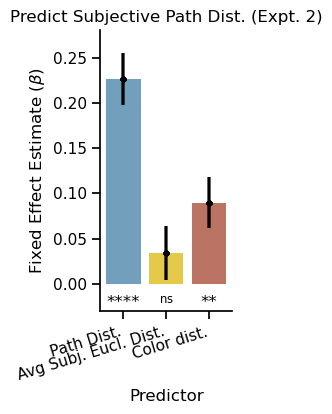

In [85]:
from pymer4.models import Lmer

connect_predictors = [
    'spd_m_flat', 
    'avg_subj_eucd_m_flat', 
    'color_m_flat', 
]

pred_str = [ f'{s}'for s in connect_predictors]
pred_str = " + ".join(pred_str)

response = "subj_spd_m_flat"
model = Lmer(f'{response} ~ {pred_str} + (1|subject_id)', data=mm4_dt_unc, family="gaussian", )
results = model.fit()

fig, ax = plt.subplots(1,1, figsize=(2.4,4.3))
spa.axplot_fixed_effects(
    model.fixef, errors=results["SE"], p_vals=results["P-val"], 
    p_val_pos=-0.02, ax=ax, label_rotation=17,
    skip_eucd=False, skip_wspd=False,
    label_ha="right",
    )
ax.set_ylim([-0.03, 0.28])
ax.set_title("Predict Subjective Path Dist. (Expt. 2)")
plt.tight_layout()

# Correlate gen data with true data
corr = scipy.stats.spearmanr(model.fits, mm4_dt_unc[response])
print(f"Corr. of true and gen data: spearm={corr[0]:.2f}, p_val={corr[1]:.4f}")

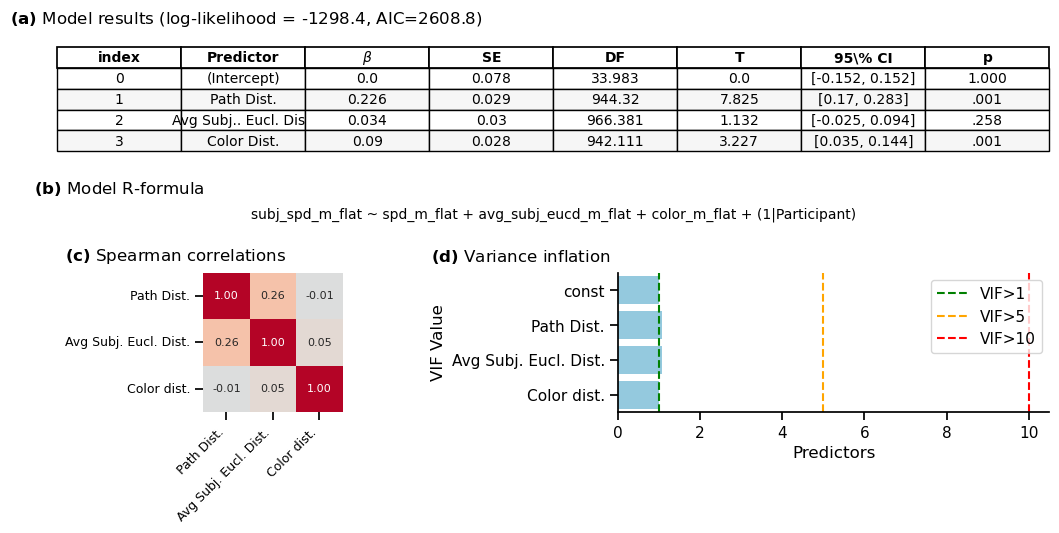

In [86]:
fig = smm.plot_model_specs(mm4_dt_unc, results, model, height_ratios=[1.2, 0.35, 1.3], fig_size=(12.8, 4.9))
plt.show()

In [87]:
res = results
dt = mm4_dt_unc
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrrll}
\hline
Predictor & $\beta$ & SE & DF & T & p & 95\% CI \\
\hline
(Intercept) & 0.00 & 0.08 & 33.98 & 0.00 & 1.000 & [-0.152, 0.152] \\
Path Dist. & 0.23 & 0.03 & 944.32 & 7.83 & .001 & [0.17, 0.283] \\
Avg Subj. Eucl. Dist. & 0.03 & 0.03 & 966.38 & 1.13 & .258 & [-0.025, 0.094] \\
Color dist. & 0.09 & 0.03 & 942.11 & 3.23 & .001 & [0.035, 0.144] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{Path Dist.} & 1.073 \\
\makecell[l]{Avg Subj. Eucl. Dist.} & 1.076 \\
\makecell[l]{Color dist.} & 1.003 \\
\hline
\end{tabular}
\end{table}


### All Predictor Correlations

In [88]:
dt = mm4_dt_unc.copy()
dt = mm4_dt_unc[~mm4_dt_unc["subject_id"].isin(sad.subjects_not_connect(mm3_unc, mm3=True))].copy()

corr_m =  dt[[
    'spd_m_flat',
    "avg_subj_spd_m_flat",
    "subj_spd_m_flat",
    "avg_learn_eucd_m_flat",
    "avg_subj_eucd_m_flat",
    'subj_eucd_m_flat',
    "color_m_flat",
]].corr(method="spearman")

print(spa.corr_df_to_latex(corr_m))

\begin{table}[h!]
\centering
\scriptsize
\setlength{\tabcolsep}{2pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{lrrrrrrr}
\hline
 & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Path Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Avg Subj. Path Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Subj. Path Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Avg Learn Eucl. Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Avg Subj. Eucl. Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Subj. Eucl. Dist.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{Color dist.}} \\
\hline
Path Dist. & 1.00 & 0.84 & 0.27 & 0.63 & 0.27 & 0.15 & -0.01 \\
Avg Subj. Path Dist. & 0.84 & 1.00 & 0.19 & 0.58 & 0.38 & 0.14 & -0.01 \\
Subj. Path Dist. & 0.27 & 0.19 & 1.00 & 0.16 & 0.10 & 0.39 & 0.09 \\
Avg Learn Eucl. Dist. & 0.63 & 0.58 & 0.16 & 1.00 & 0.21 & 0.13 & 0.01 \\
Avg Subj. Eucl. Dist. & 0.27 & 0.38 & 0.10 & 0.21 & 1.00 & 0.09 & 0.05 \\
Subj. Eucl. Dist. & 0.15 & 0.14 & 0.39 & 0.13 & 0.09 

/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:631: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_fmt = df.applymap(_fmt)
